# ✅ Solutions — Session 3: Subplots, Layouts & Annotations

Worked solutions to all five exercises and the mini project.
Run each cell top to bottom.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(3)

## Exercise 1 (Easy) — A 2×2 grid of simple functions

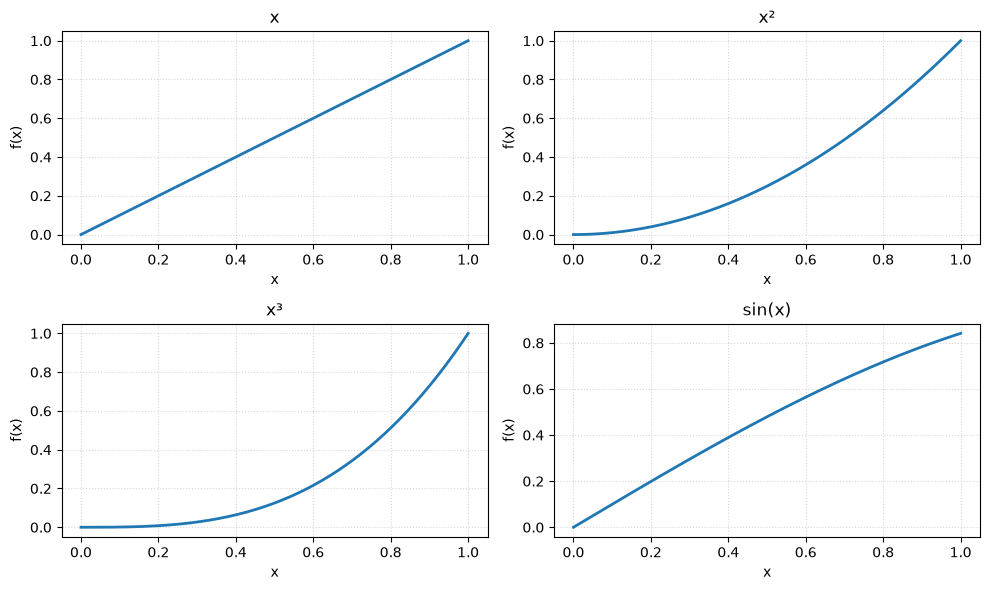

In [2]:
x = np.linspace(0, 1, 200)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
functions = [("x", x), ("x²", x ** 2), ("x³", x ** 3), ("sin(x)", np.sin(x))]

for ax, (name, f) in zip(axes.ravel(), functions):
    ax.plot(x, f, color="tab:blue", linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

## Exercise 2 (Easy) — Shared y-axis with a single shared label

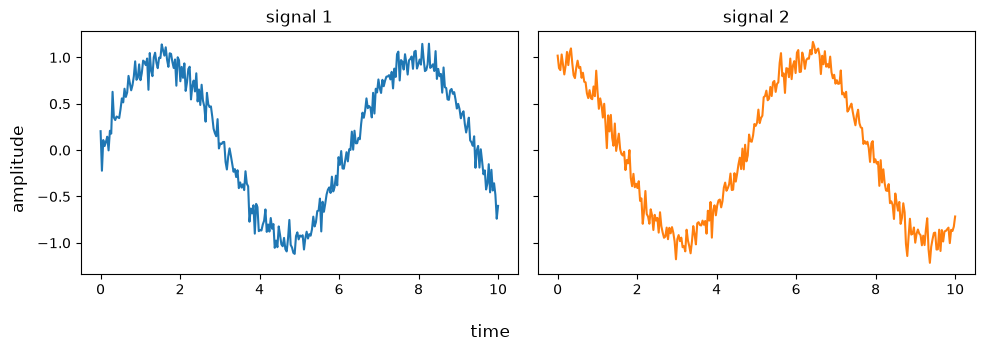

In [3]:
t = np.linspace(0, 10, 300)
signal1 = np.sin(t) + rng.normal(scale=0.1, size=t.size)
signal2 = np.cos(t) + rng.normal(scale=0.1, size=t.size)

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 3.5))
axes[0].plot(t, signal1, color="tab:blue")
axes[1].plot(t, signal2, color="tab:orange")
axes[0].set_title("signal 1")
axes[1].set_title("signal 2")
fig.supxlabel("time")
fig.supylabel("amplitude")
fig.tight_layout()
plt.show()

## Exercise 3 (Medium) — GridSpec with a full-width hero panel

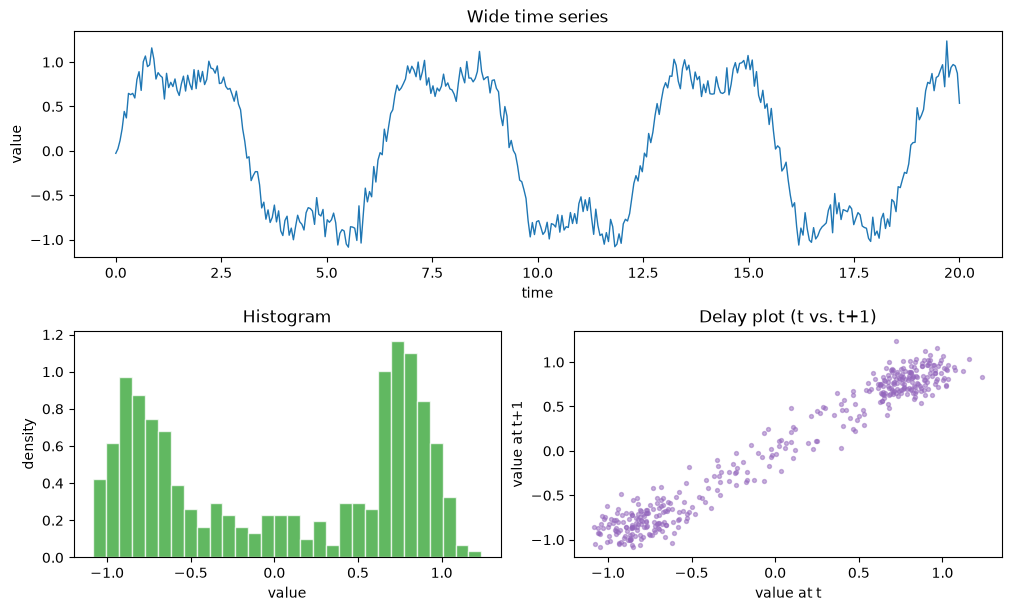

In [4]:
ts = np.linspace(0, 20, 400)
series = np.sin(ts) + 0.3 * np.sin(3 * ts) + rng.normal(scale=0.1, size=ts.size)

fig = plt.figure(figsize=(10, 6), layout="constrained")
gs = fig.add_gridspec(2, 2)

ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(ts, series, color="tab:blue", linewidth=1)
ax_top.set_title("Wide time series")
ax_top.set_xlabel("time")
ax_top.set_ylabel("value")

ax_hist = fig.add_subplot(gs[1, 0])
ax_hist.hist(series, bins=30, density=True, color="tab:green", alpha=0.75,
             edgecolor="white")
ax_hist.set_title("Histogram")
ax_hist.set_xlabel("value")
ax_hist.set_ylabel("density")

# Delay plot: each value against the next one
ax_delay = fig.add_subplot(gs[1, 1])
ax_delay.scatter(series[:-1], series[1:], s=8, alpha=0.5, color="tab:purple")
ax_delay.set_title("Delay plot (t vs. t+1)")
ax_delay.set_xlabel("value at t")
ax_delay.set_ylabel("value at t+1")

plt.show()

## Exercise 4 (Medium) — Conceptual: sharing axes

`sharex=True` links the x-axis across panels: they use the same limits and
ticks, and zooming or panning one panel changes them all. It is good practice
when two panels show the **same** x variable, because it removes redundant
tick labels and prevents the reader from comparing panels with different
ranges — which can make an identical difference look bigger or smaller.

Sharing an axis would be **misleading** when the panels genuinely measure
different quantities on different scales. For example, plotting a temperature
series and a stock price on a shared y-axis would force unrelated ranges onto
one scale and suggest a relationship that does not exist.

## Exercise 5 (Advanced) — Annotating extrema and shading a region

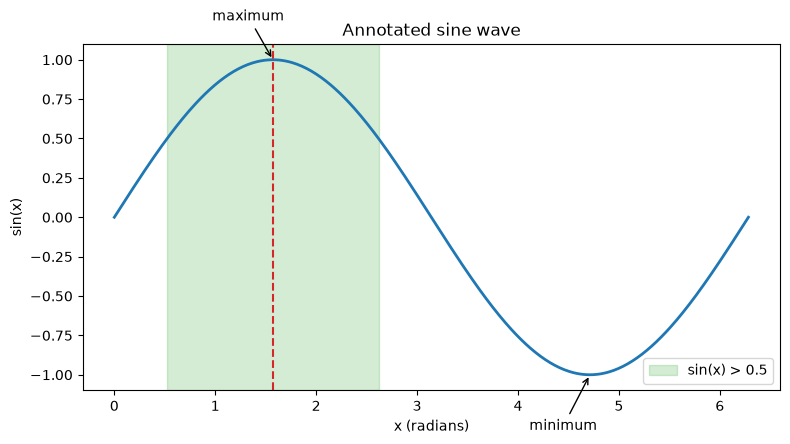

In [5]:
xs = np.linspace(0, 2 * np.pi, 400)
ys = np.sin(xs)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(xs, ys, color="tab:blue", linewidth=2)

ax.annotate(
    "maximum",
    xy=(np.pi / 2, 1.0),
    xytext=(np.pi / 2 - 0.6, 1.25),
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.annotate(
    "minimum",
    xy=(3 * np.pi / 2, -1.0),
    xytext=(3 * np.pi / 2 - 0.6, -1.35),
    arrowprops=dict(arrowstyle="->", color="black"),
)

ax.axvline(np.pi / 2, color="tab:red", linestyle="--")
ax.axvspan(np.pi / 6, 5 * np.pi / 6, color="tab:green", alpha=0.2,
           label="sin(x) > 0.5")

ax.set_title("Annotated sine wave")
ax.set_xlabel("x (radians)")
ax.set_ylabel("sin(x)")
ax.legend(loc="lower right")
plt.show()

## 🚀 Mini Project — 2×2 Dashboard

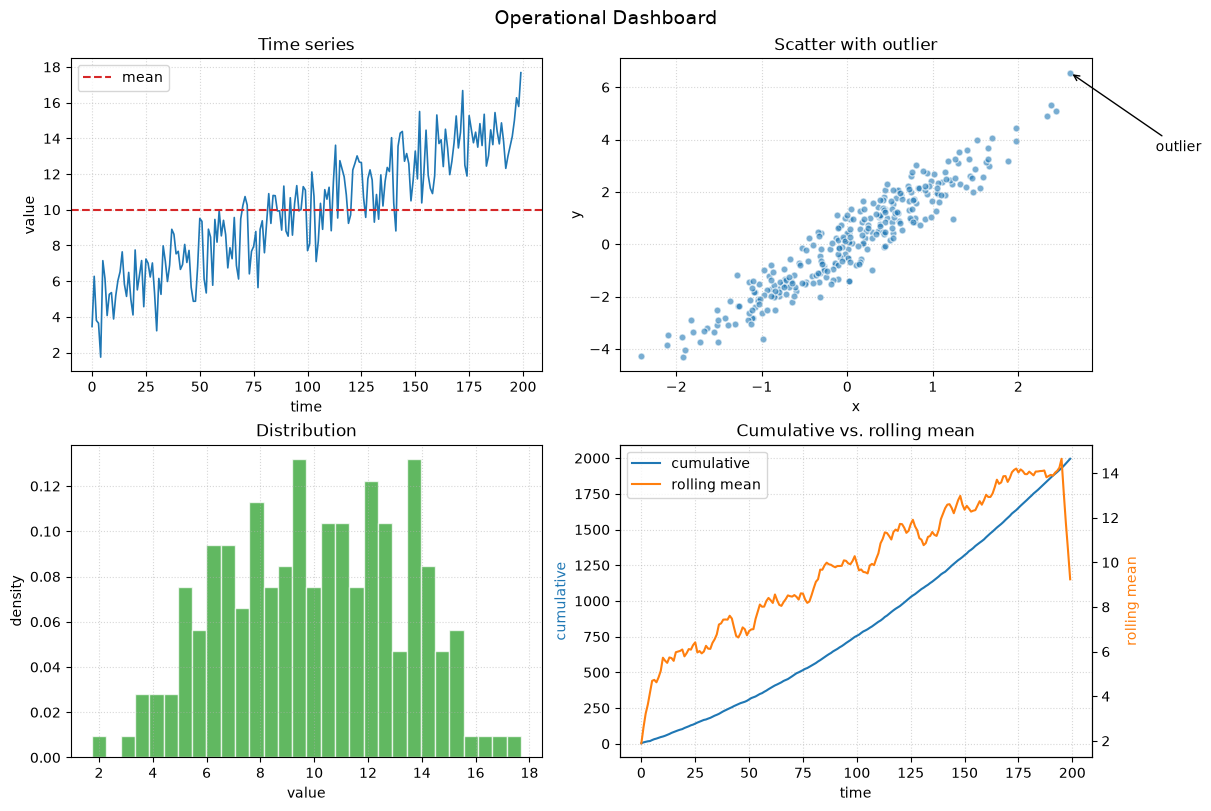

In [6]:
t = np.arange(200)
trend = 0.05 * t
series = trend + 5 + rng.normal(scale=1.5, size=t.size)

x_scatter = rng.normal(size=300)
y_scatter = 2 * x_scatter + rng.normal(scale=0.6, size=300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")

# Top-left: time series with a mean reference line
ax = axes[0, 0]
ax.plot(t, series, color="tab:blue", linewidth=1.2)
ax.axhline(series.mean(), color="tab:red", linestyle="--", label="mean")
ax.set_title("Time series")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)

# Top-right: scatter with an annotated outlier
ax = axes[0, 1]
ax.scatter(x_scatter, y_scatter, s=25, alpha=0.6, edgecolors="white")
outlier_idx = int(np.argmax(np.abs(x_scatter)))
ax.annotate(
    "outlier",
    xy=(x_scatter[outlier_idx], y_scatter[outlier_idx]),
    xytext=(x_scatter[outlier_idx] + 1.0, y_scatter[outlier_idx] - 3.0),
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.set_title("Scatter with outlier")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, linestyle=":", alpha=0.5)

# Bottom-left: histogram of the time-series values
ax = axes[1, 0]
ax.hist(series, bins=30, density=True, color="tab:green", alpha=0.75,
        edgecolor="white")
ax.set_title("Distribution")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.grid(True, linestyle=":", alpha=0.5)

# Bottom-right: cumulative sum on the left, rolling average on the right
ax = axes[1, 1]
ax2 = ax.twinx()
cumulative = np.cumsum(series)
window = 10
rolling = np.convolve(series, np.ones(window) / window, mode="same")

line1, = ax.plot(t, cumulative, color="tab:blue", label="cumulative")
ax.set_ylabel("cumulative", color="tab:blue")
line2, = ax2.plot(t, rolling, color="tab:orange", label="rolling mean")
ax2.set_ylabel("rolling mean", color="tab:orange")
ax.set_title("Cumulative vs. rolling mean")
ax.set_xlabel("time")
ax.legend(handles=[line1, line2], loc="upper left")
ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Operational Dashboard", fontsize=14)
fig.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()